In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [12]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print(y[:10])

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

print()

print(classification_report(y_test, y_pred))

Confusion Matrix
[[41  1]
 [ 1 71]]

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



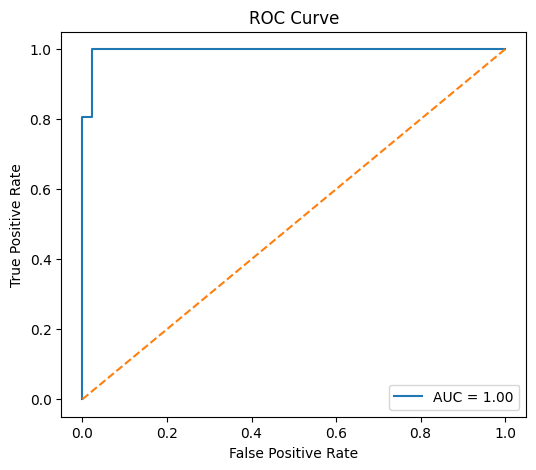

AUC Score = 0.9953703703703703


In [17]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="AUC = %.2f"%auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score =",auc)

In [18]:
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(X_train_scaled,y_train)

balanced_pred = balanced_model.predict(X_test_scaled)

print(classification_report(y_test,balanced_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [19]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)

print(classification_report(y_test,tree_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [20]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)

print(classification_report(y_test,tree_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



# 1. Difference Between Classification and Regression

Classification predicts categorical values or classes such as Spam/Not Spam, Yes/No, or Benign/Malignant.

Regression predicts continuous numerical values such as house prices, temperature, or salary.

Example:
- Classification: Predict whether a tumor is malignant or benign.
- Regression: Predict the price of a house.

# 2. What is a Confusion Matrix?

A Confusion Matrix is a table used to evaluate the performance of a classification model.

It contains four values:

- True Positive (TP): Correctly predicted positive cases.
- True Negative (TN): Correctly predicted negative cases.
- False Positive (FP): Incorrectly predicted positive cases.
- False Negative (FN): Incorrectly predicted negative cases.

The confusion matrix helps us understand how well the model is performing.

# 3. Why is Accuracy Not Enough?

Accuracy measures the overall percentage of correct predictions.

However, in imbalanced datasets, a model may achieve high accuracy while failing to identify the minority class.

Therefore, Precision, Recall, and F1-Score are more reliable evaluation metrics.

# 4. Precision

Precision measures how many predicted positive cases are actually positive.

Formula:

Precision = TP / (TP + FP)

A high Precision means fewer false positive predictions.

# 5. Recall

Recall measures how many actual positive cases are correctly identified.

Formula:

Recall = TP / (TP + FN)

High Recall is very important in medical diagnosis because missing a disease can be dangerous.

# 6. F1-Score

F1-Score is the harmonic mean of Precision and Recall.

Formula:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

It provides a balanced evaluation when dealing with imbalanced datasets.

# 7. ROC Curve and AUC

ROC (Receiver Operating Characteristic) Curve shows the relationship between the True Positive Rate and False Positive Rate.

AUC (Area Under the Curve) measures the overall performance of the classifier.

- AUC = 1.0 indicates a perfect model.
- AUC = 0.5 indicates random guessing.

Higher AUC values indicate better classification performance.

# 8. Handling Imbalanced Data

An imbalanced dataset contains one class with many more samples than the other.

One simple solution is to use:

class_weight = "balanced"

This gives more importance to the minority class during training and improves prediction performance.

# 9. Logistic Regression vs Decision Tree

Logistic Regression:
- Simple and fast.
- Easy to interpret.
- Works well for linear decision boundaries.

Decision Tree:
- Easy to visualize.
- Can capture complex relationships.
- May overfit if not properly controlled.